# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Кутельмах Євген Петрович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'      # напр. 'КН-31'
ВАРІАНТ = 8     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 8 · Кутельмах Євген Петрович, ШІ-34, «Друк-Сервіс»
Підприємство «Друк-Сервіс» виготовляє поліграфію. Одиниця виміру плану: тис. прим./тиждень.

                          Буклет  Каталог  Календар  Плакат  ЗАПАС
Крейдований папір, кг          2        1         3       5   1279
Офсетний папір, кг             3        1         0       6    761
Фарба, кг                      1        6         1       5    376
Друкарська машина, год         2        2         4       0   1230
Різка й фальцювання, год       6        1         2       2   1065

                    Буклет  Каталог  Календар  Плакат
Прибуток з одиниці      60       25        59      25

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Друкарська машина, год
  ціна:   9.5 за одиницю
  обсяг:  до 234 одиниць


In [3]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x1 - кількість тис. прим. / тиждень буклетів, x2 - каталогів, х3 - календарів, х4 - плакатів

Цільова функція: 60х1 + 25х2 + 59х3 + 25х4 => max - максимізація прибутку

Обмеження: 2х1 + 1х2 + 3х3 + 5х4 <= 1279 кг - обмеження крейдованого паперу
           3х1 + 1х2 + 0х3 + 6х4 <= 761 кг - обмеження офсетного паперу
           1х1 + 6х2 + 1х3 + 5х4 <= 376 кг - обмеження фарби
           2х1 + 2х2 + 4х3 + 0х4 <= 1230 год - обмеження друкарської машини
           6х1 + 1х2 + 2х3 + 2х4 <= 1065 год - обмеження на різку й фальцювання

Невід'ємність: x1,x2,x3,x4 >= 0 - кількість вироблених товарів не може бути від'ємною


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:**

Запас ресурсу - це обмеження, яке задає область допустимих значень для функції, якби ресурс був би змінною, то задача була б необмеженою

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [4]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [88.04166667, 0, 263.4791667, 4.895833333]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 20950.16667             # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [88.04166667, 0, 263.4791667, 4.895833333] | прибуток 20950.16667


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [5]:
# ВАШ КОД
func = np.array([60, 25, 59, 25])

limits_A = np.array([
    [2, 1, 3, 5],
    [3, 1, 0, 6],
    [1, 6, 1, 5],
    [2, 2, 4, 0],
    [6, 1, 2, 2]
])
limits_b = np.array([1279, 761, 376, 1230, 1065])

solution = linprog(c=-func, A_ub=limits_A, b_ub=limits_b, bounds=(0, None), method='highs')

план = solution.x
прибуток = -solution.fun


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [6]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Крейдований папір, кг | 991 | 0 | 1279 | 1E+30 | 288 |
| Офсетний папір, кг | 293,5 | 0 | 761 | 1E+30 | 467,5 |
| Фарба, кг | 376 | 2,666666667 | 376 | 288 | 23,5 |
| Друкарська машина, год | 1230 | 11,16666667 | 1230 | 117,5 | 903,3571429 |
| Різка й фальцювання, год | 1065 | 5,833333333 | 1065 | 235 | 422,6 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**


Крейдований папір та офсетний папір в профіциті, решта в дефіциті. Це видно за різницею правої частини та кінцевого значення, а також тіньовою ціною

### Завдання 4.2 — блок «Змінні»

| Виріб | Остаточне Значення | Зменшена Вартість | Цільова функція Коефіцієнт | Припустиме Збільшення | Припустиме Зменшення |
|---|---|---|---|---|---|
| Буклет | 88,04166667 | 0 | 60 | 32 | 28 |
| Каталог | 0 | -19,16666667 | 25 | 19,16666667 | 1E+30 |
| Календар | 263,4791667 | 0 | 59 | 56 | 26,28571429 |
| Плакат | 4,895833333 | 0 | 25 | 268 | 12,8 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?


Не виробляється каталог, щоб стало вигідно виготовляти даний тип продукції, його прибутковість мала б зрости на хоча б 19,16666667. Це видно з колонки "Зменшена вартість" та "Припустиме збільшення"

---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [7]:
# ВАШ КОД
limits_b_5_1 = np.array([1279, 761, 376, 1231, 1065]) # 1230 + 1 до годин друкарської машини

solution_5_1 = linprog(c=-func, A_ub=limits_A, b_ub=limits_b_5_1, bounds=(0, None), method='highs')
print("Різниця прибутку:", -solution_5_1.fun + solution.fun)


Різниця прибутку: 11.166666666671517


**Відповідь 5.1:** *(приріст прибутку = ..., тіньова ціна зі звіту = ..., збігаються?)*

Так, вони збігаються

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

Межа припустимого збільшення (цілочисельно): 1347


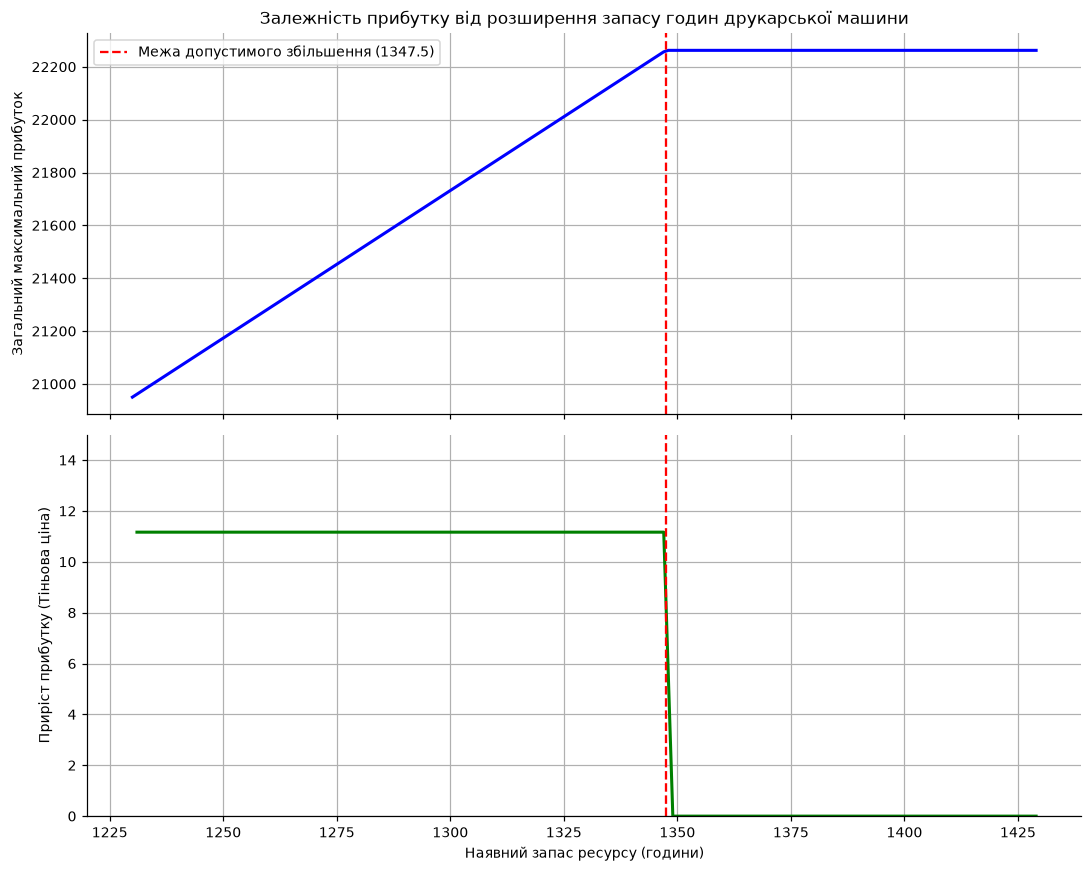

In [8]:
# ВАШ КОД
capacities = np.arange(1230, 1430)
def get_profit(cap):
    b = limits_b.copy()
    b[3] = cap
    return -linprog(c=-func, A_ub=limits_A, b_ub=b, bounds=(0, None), method='highs').fun

profits = np.array([get_profit(cap) for cap in capacities])
marginal_profits = np.diff(profits)
capacities_marg = capacities[1:]

initial_margin = marginal_profits[0]
drop_indices = np.where(marginal_profits < initial_margin - 1e-5)[0]
x_threshold = capacities_marg[drop_indices[0]] - 1
print("Межа припустимого збільшення (цілочисельно):", x_threshold)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(capacities, profits, color='blue', linewidth=2)
ax1.set_ylabel('Загальний максимальний прибуток')
ax1.set_title('Залежність прибутку від розширення запасу годин друкарської машини')
ax1.grid(True)
ax1.axvline(x=1347.5, color='red', linestyle='--', label='Межа допустимого збільшення (1347.5)')
ax1.legend()

ax2.plot(capacities_marg, marginal_profits, color='green', linewidth=2)
ax2.set_xlabel('Наявний запас ресурсу (години)')
ax2.set_ylabel('Приріст прибутку (Тіньова ціна)')
ax2.grid(True)
ax2.axvline(x=1347.5, color='red', linestyle='--')
ax2.set_ylim(bottom=0, top=15) 

plt.tight_layout()
plt.show()

**Відповідь 5.2:** *(на скільки одиниць можна збільшити запас, доки тіньова ціна не зміниться;
чи збігається знайдена межа з «допустимим збільшенням» зі звіту Excel)*

Запас годин друкарської машини можна збільшити на 117.5 годин, далі прибуток не збільшується. Параметр "Припустиме збільшення" з excel збігається з побудованим графіком 

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [9]:
# ВАШ КОД
# Друкарська машина
# ціна:   9.5 за одиницю
# обсяг:  до 234 одиниць

max_increase = x_threshold - limits_b[3]
profit_increase = -solution_5_1.fun + solution.fun

print("Чи варто брати?:", "Tak" if profit_increase > 9.5 else "Ні")
print("Варто брати:", min(max_increase, 234))
print("Заробимо:", min(max_increase, 234) * (profit_increase - 9.5))

Чи варто брати?: Tak
Варто брати: 117
Заробимо: 195.00000000056752


**Відповідь 6.1:**

* Брати чи ні і чому:
* Скільки одиниць має сенс купити і чому не більше:
* Очікуваний виграш:
* Перевірка прямим розв'язанням дала:


Перевірка прямим розв'язком підтверджує аналіз excel, варто взяти 117 одиниць (117.5 якщо не цілочисельно) з очікуваним прибутком в 195 одиниць.

---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [10]:
# ВАШ КОД
ненульових = np.sum(solution.x > 1e-5)
звязних = np.sum(solution.slack < 1e-5)
print(f"Є {ненульових} ненульових виробів та {звязних} звязних виробів")


Є 3 ненульових виробів та 3 звязних виробів


In [11]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 3 | зв’язних обмежень: 3
Етап 7 пройдено


**Відповідь 7.1:** *(чи збіглися числа; що означала б розбіжність на практиці)*

Так, числа збіглися. Розбіжність означала б, що знайдений розв'язок не оптимальний

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [12]:
# ВАШ КОД
not_z = -solution.fun
plan_continuous = solution.x
print(f"План без умови цілочисельності: {plan_continuous}")
print(f"Розв'язок без умови цілочисельності: {not_z}\n")

plan_rounded = solution.x.astype(int)
not_z_changed = (func * plan_rounded).sum()
print(f"Заокруглений план: {plan_rounded}")
print(f"Заокруглений розв'язок: {not_z_changed}\n")

z = linprog(c=-func, A_ub=limits_A, b_ub=limits_b, bounds=(0, None), method='highs', integrality=1)
plan_integer = z.x
print(f"Цілочисельний план: {plan_integer}")
print(f"Цілочисельний розв'язок: {-z.fun}")

План без умови цілочисельності: [ 88.04166667   0.         263.47916667   4.89583333]
Розв'язок без умови цілочисельності: 20950.166666666664

Заокруглений план: [ 88   0 263   4]
Заокруглений розв'язок: 20897

Цілочисельний план: [ 88.   0. 263.   5.]
Цілочисельний розв'язок: 20922.0


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | [ 88.04166667   0.         263.47916667   4.89583333] | 20950.166666666664 | Ні |
| округлений | [ 88   0 263   4] | 20897 | Так |
| цілочисельний оптимум | [ 88.   0. 263.   5.] | 20922.0 | Так |

**Висновок:** *(чи можна округлювати і чому)*

Так, можна, адже ми ми заокрулюємо вниз, а умова <=, тобто ми не вийдемо за ОДЗ.

---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [13]:
# ВАШ КОД — впишіть свої дані
постачальники = ["Краків", "Умань", "Тернопіль"]            # напр. ['Шостка', 'Енергодар', 'Вінниця']
споживачі     = ["Євпаторія", "Вінниця", "Гостомель", "Енергодар"]            # напр. ['Тернопіль', 'Афанасіївка', 'Рівне', 'Апостолове']
D = np.array([
    [1460, 610, 860, 1270],
    [540,  160, 240, 480],
    [960,  240, 420, 840]
])              # матриця відстаней 3 x 4, км
запас = [5, 1, 8]                    # 3 числа
попит = [2, 3, 6, 3]                    # 4 числа

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Євпаторія,Вінниця,Гостомель,Енергодар
Краків,1460,610,860,1270
Умань,540,160,240,480
Тернопіль,960,240,420,840


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [14]:
# ВАШ КОД — розв'язок 1
c = D.flatten()

A_eq = np.zeros((7, 12))
for i in range(3):
    A_eq[i, i*4:(i+1)*4] = 1
for j in range(4):
    A_eq[3+j, j::4] = 1

b_eq = np.concatenate([запас, попит])

res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')

print("Оптимальний план перевезень:")
plan_scipy = pd.DataFrame(res.x.reshape(3, 4), index=постачальники, columns=споживачі)
print(plan_scipy)
print(f"\nСумарна вартість: {res.fun}")

print("\nТіньові ціни обмежень:")
scipy_shadows = res.eqlin.marginals
for i, p in enumerate(постачальники):
    print(f"Запас {p}: {scipy_shadows[i]}")
for j, cons in enumerate(споживачі):
    print(f"Попит {cons}: {scipy_shadows[3+j]}")

Оптимальний план перевезень:
           Євпаторія  Вінниця  Гостомель  Енергодар
Краків           0.0      3.0        0.0        2.0
Умань            1.0      0.0        0.0        0.0
Тернопіль        1.0      0.0        6.0        1.0

Сумарна вартість: 9230.0

Тіньові ціни обмежень:
Запас Краків: -0.0
Запас Умань: -850.0
Запас Тернопіль: -430.0
Попит Євпаторія: 1390.0
Попит Вінниця: 610.0
Попит Гостомель: 850.0
Попит Енергодар: 1270.0


In [15]:
from ortools.linear_solver import pywraplp

solver = pywraplp.Solver.CreateSolver('GLOP')

x = {}
for i in range(3):
    for j in range(4):
        x[i, j] = solver.NumVar(0, solver.infinity(), f'x_{i}_{j}')

objective = solver.Objective()
for i in range(3):
    for j in range(4):
        objective.SetCoefficient(x[i, j], float(D[i][j]))
objective.SetMinimization()

supply_constraints = []
for i in range(3):
    constraint = solver.Constraint(запас[i], запас[i])
    for j in range(4):
        constraint.SetCoefficient(x[i, j], 1)
    supply_constraints.append(constraint)

demand_constraints = []
for j in range(4):
    constraint = solver.Constraint(попит[j], попит[j])
    for i in range(3):
        constraint.SetCoefficient(x[i, j], 1)
    demand_constraints.append(constraint)

solver.Solve()

print("Оптимальний план перевезень:")
plan = np.zeros((3, 4))
for i in range(3):
    for j in range(4):
        plan[i, j] = x[i, j].solution_value()
        
print(pd.DataFrame(plan, index=постачальники, columns=споживачі))
print(f"\nСумарна вартість: {objective.Value()}")

shadow_supply_ort = [c.dual_value() for c in supply_constraints]
shadow_demand_ort = [c.dual_value() for c in demand_constraints]

print(f"\nТіньові ціни запасів: {shadow_supply_ort}")
print(f"Тіньові ціни попиту:  {shadow_demand_ort}")

Оптимальний план перевезень:
           Євпаторія  Вінниця  Гостомель  Енергодар
Краків           0.0      3.0        0.0        2.0
Умань            1.0      0.0        0.0        0.0
Тернопіль        1.0      0.0        6.0        1.0

Сумарна вартість: 9230.0

Тіньові ціни запасів: [1270.0, 420.0, 840.0]
Тіньові ціни попиту:  [120.0, -660.0, -420.0, 0.0]


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [16]:
# ВАШ КОД — порівняння
shadow_supply_lp = res.eqlin.marginals[:3]  
shadow_demand_lp = res.eqlin.marginals[3:]

diff_supply = np.round(shadow_supply_ort - shadow_supply_lp, 4)
diff_demand = np.round(shadow_demand_ort - shadow_demand_lp, 4)

print("Різниця тіньових цін:")
print(f"Постачальники: {diff_supply}")
print(f"Споживачі:     {diff_demand}")

Різниця тіньових цін:
Постачальники: [1270. 1270. 1270.]
Споживачі:     [-1270. -1270. -1270. -1270.]


**Відповідь 10.2:**

* Вартість у двох розв'язувачів: 9230.0
* Тіньові ціни збіглися чи ні: ні 
* Яку закономірність ви побачили в різниці: Різниця в тіньових цінах для постачальників 1270, а у споживачів -1270.
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: оскільки система має перебувати замкнутою (попит == пропозиція), людині варто дивитись на пару постачальник-споживач, в такому випадку перетворення буде дійсним і тіньові ціни відображатимуть справжню картину. Так відбувається, тому що одне з рівнянь балансу є надлишковим, отже двоїста задача має безліч оптимальних розв'язків


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [17]:
# ВАШ КОД
non_zero_shipments = np.sum(res.x > 0)

actual_used = np.round(A_eq @ res.x, 4)
binding_constraints = np.sum(actual_used == b_eq)

print(f"Кількість ненульових перевезень: {non_zero_shipments}")
print(f"Кількість зв'язних обмежень:     {binding_constraints}")
print(f"Загальна кількість обмежень (m+n): {len(b_eq)}")

Кількість ненульових перевезень: 6
Кількість зв'язних обмежень:     7
Загальна кількість обмежень (m+n): 7


**Відповідь 11.1:**

* Ненульових перевезень: 6
* Зв'язних обмежень: 7
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження: бо система замкнута і весь ресурс має бути розподілений
* На скільки ненульових перевезень менше і чому саме на стільки: менше на -1, тому що ранг матриці обмежень m + n - 1, кількість ненульових змінних рівна рангу матриці. Це наслідок згаданого вище факту лінійної залежності одного з рівняннь


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

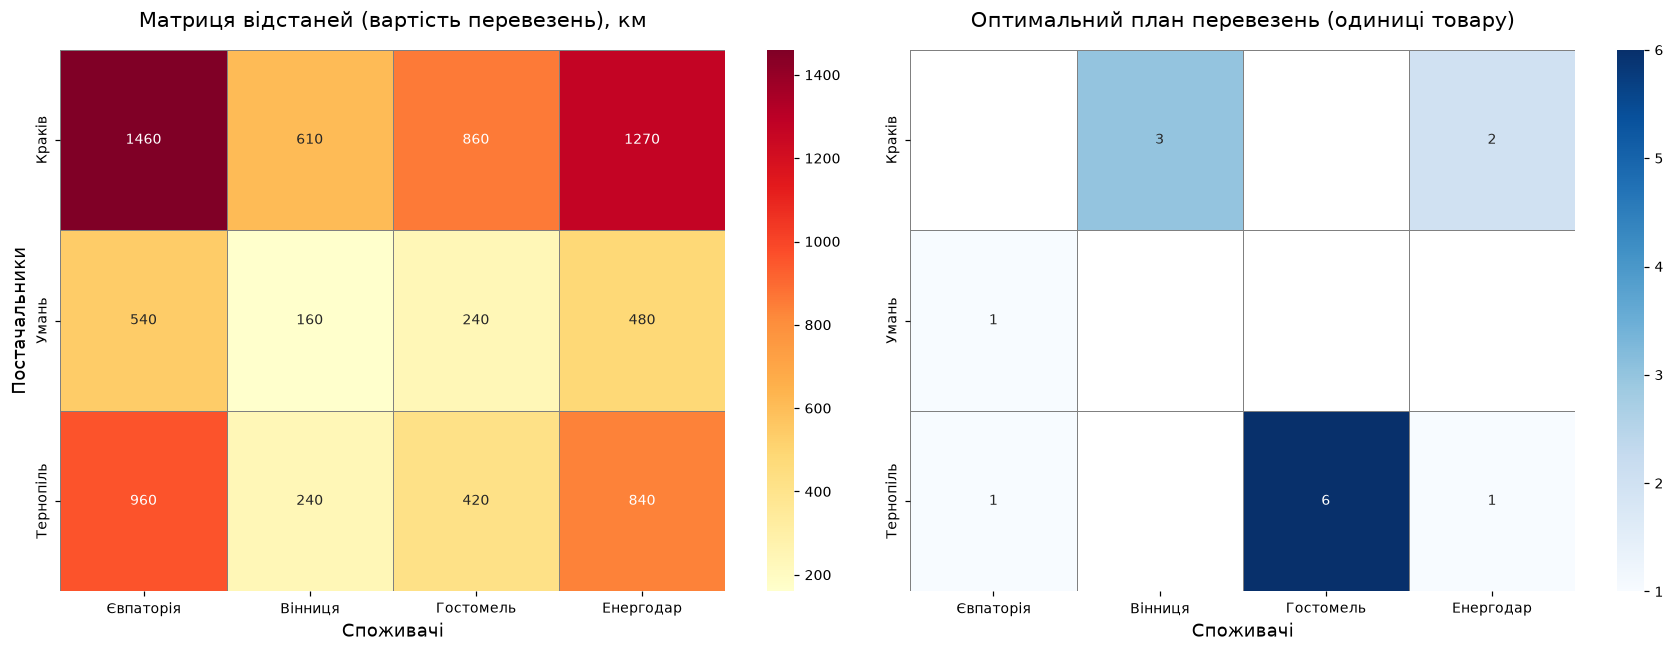

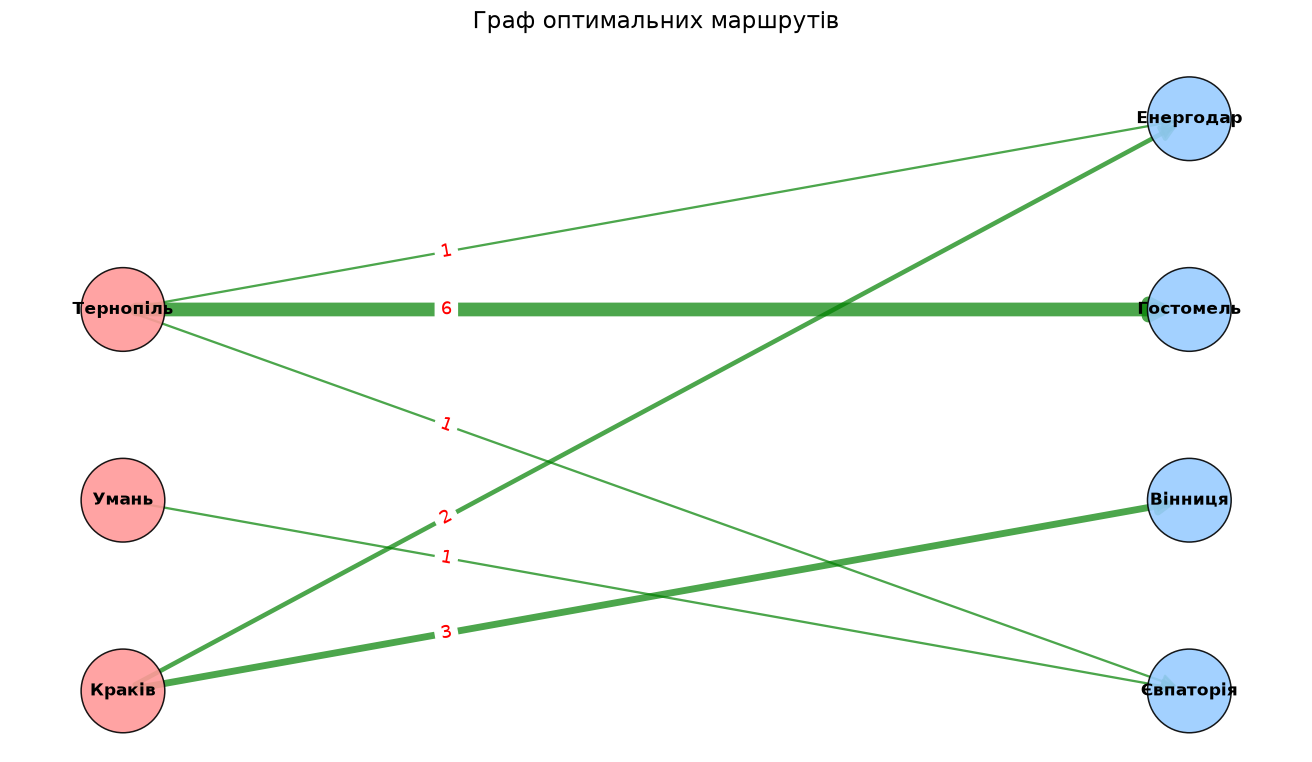

In [18]:
# ВАШ КОД
import seaborn as sns
import networkx as nx

plan = res.x.reshape(3, 4)
df_plan = pd.DataFrame(plan, index=постачальники, columns=споживачі)
df_D = pd.DataFrame(D, index=постачальники, columns=споживачі)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df_D, annot=True, fmt="d", cmap="YlOrRd", cbar=True, ax=axes[0], 
            linewidths=0.5, linecolor='gray')
axes[0].set_title('Матриця відстаней (вартість перевезень), км', fontsize=14, pad=15)
axes[0].set_ylabel('Постачальники', fontsize=12)
axes[0].set_xlabel('Споживачі', fontsize=12)

mask = plan == 0 
sns.heatmap(df_plan, annot=True, fmt="g", cmap="Blues", cbar=True, ax=axes[1], 
            linewidths=0.5, linecolor='gray', mask=mask)
axes[1].set_title('Оптимальний план перевезень (одиниці товару)', fontsize=14, pad=15)
axes[1].set_ylabel('')
axes[1].set_xlabel('Споживачі', fontsize=12)

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 7))
G = nx.DiGraph()

for p in постачальники: G.add_node(p, bipartite=0)
for c in споживачі: G.add_node(c, bipartite=1)

edges = []
weights = []
for i, p in enumerate(постачальники):
    for j, c in enumerate(споживачі):
        if plan[i, j] > 0:
            G.add_edge(p, c, weight=plan[i, j])
            edges.append((p, c))
            weights.append(plan[i, j])

pos = {}
pos.update((node, (1, index)) for index, node in enumerate(постачальники))
pos.update((node, (2, index)) for index, node in enumerate(споживачі))

nx.draw_networkx_nodes(G, pos, node_color=['#ff9999' if n in постачальники else '#99ccff' for n in G.nodes()], 
                       node_size=3000, alpha=0.9, edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=11, font_weight="bold")

edge_widths = [w * 1.5 for w in weights]
nx.draw_networkx_edges(G, pos, edgelist=edges, width=edge_widths, 
                       edge_color='green', arrowsize=20, alpha=0.7)

edge_labels = {(u, v): f"{d['weight']:g}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=12, label_pos=0.3)

plt.title('Граф оптимальних маршрутів', fontsize=15, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

**Висновок:** *(одне речення про те, що видно на теплових картах)*

Теплові мапи візуалізують вартість поїздок та підсумковий розподіл товарів між маршрутами

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [19]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'ні',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'ні',
    'етапи 7–8, перевірка та цілочисельність': 'синтаксис',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'Чи правильно побудовано графіки, теплові мапи та граф маршрутів, чи транспортну задачу коректно розвязано бібліотекою ortools'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [20]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Кутельмах Євген Петрович
інструменти:                               Gemini
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     ні
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             ні
етапи 7–8, перевірка та цілочисельність:   синтаксис
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
Чи правильно побудовано графіки, теплові мапи та граф маршрутів, чи транспортну задачу коректно розвязано бібліотекою ortools


---
# Крок 13. Фінальна самоперевірка

In [21]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
